In [2]:
import sys, subprocess
print("Kernel Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip", "pandas", "pingouin", "seaborn", "ipython", "openpyxl", "numpy", "matplotlib", "japanize-matplotlib", "factor-analyzer", "statsmodels", "scikit_posthocs"])
# ノートブック内から導入

Kernel Python: c:\Users\yuki4\AppData\Local\Programs\Python\Python310\python.exe


0

In [3]:
import pandas as pd
import seaborn
from IPython.display import display
import openpyxl

df_Courage = pd.read_excel('scene1_2nd.xlsx', sheet_name='勇気', usecols='A:F')
df_Courage2 = pd.read_excel('scene2_2nd.xlsx', sheet_name='勇気', usecols='A:F')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from factor_analyzer import FactorAnalyzer

# 変数の標準化
df_Courage_std = df_Courage.apply(lambda x: (x-x.mean())/x.std(), axis=0)
df_Courage_std2 = df_Courage2.apply(lambda x: (x-x.mean())/x.std(), axis=0)



In [4]:
# 固有値を求める
ei = np.linalg.eigvals(df_Courage.corr())
ei2 = np.linalg.eigvals(df_Courage2.corr())
print("固有値（scene1.xlsx）:", ei)
print("固有値（scene2.xlsx）:", ei2)

固有値（scene1.xlsx）: [4.39552613 0.47034755 0.32596121 0.24160684 0.27162629 0.29493197]
固有値（scene2.xlsx）: [3.92093573 0.54219943 0.48047817 0.31117986 0.3824425  0.36276431]


In [5]:
# 因子分析（因子数 = 1）
from factor_analyzer import FactorAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

# --------- 前処理済みデータフレーム df_Courage_std を想定 ---------

# 因子分析の実行
fa = FactorAnalyzer(n_factors=1, rotation=None)   # 1因子なので回転は省略
fa.fit(df_Courage_std)

# 因子負荷量・共通性
loadings_df = pd.DataFrame(
    fa.loadings_,
    columns=["第1因子"],
    index=df_Courage_std.columns
)
loadings_df["共通性"] = fa.get_communalities()
display(loadings_df)

# 因子負荷量の二乗和・寄与率・累積寄与率
var = fa.get_factor_variance()           # (3, 1) の配列
df_var = pd.DataFrame(
    {
        "因子負荷量の二乗和": var[0],
        "寄与率": var[1],
        "累積寄与率": var[2]
    },
    index=["第1因子"]
)
display(df_var.T)



c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,第1因子,共通性
このロボットは、自身の恐怖に立ち向かうように見えた。,-0.726574,0.527910
このロボットは、たとえ強い恐れを感じていても、やるべきことをやるまでは逃げ出さないように見えた。,-0.843822,0.712035
このロボットは、たとえ危険に思えることがあっても、それをやっていた。,-0.852818,0.727298
このロボットは、何か心配や不安があっても、とにかく行動を起こすか、立ち向かっていた。,-0.832358,0.692821
このロボットは、恐ろしいことであっても、立ち向かうべき重大な理由があれば、立ち向かっていた。,-0.854849,0.730767
このロボットは、たとえ自身を脅かすものがあっても、引き下がらないように見えた。,-0.831378,0.691189


,第1因子
因子負荷量の二乗和,4.082020
寄与率,0.680337
累積寄与率,0.680337


In [6]:
# 因子分析（因子数 = 1）
from factor_analyzer import FactorAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

# --------- 前処理済みデータフレーム df_Courage_std を想定 ---------

# 因子分析の実行
fa = FactorAnalyzer(n_factors=1, rotation=None)   # 1因子なので回転は省略
fa.fit(df_Courage_std2)

# 因子負荷量・共通性
loadings_df2 = pd.DataFrame(
    fa.loadings_,
    columns=["第1因子"],
    index=df_Courage_std2.columns
)
loadings_df2["共通性"] = fa.get_communalities()
display(loadings_df2)

# 因子負荷量の二乗和・寄与率・累積寄与率
var2 = fa.get_factor_variance()           # (3, 1) の配列
df2_var = pd.DataFrame(
    {
        "因子負荷量の二乗和": var2[0],
        "寄与率": var2[1],
        "累積寄与率": var2[2]
    },
    index=["第1因子"]
)
display(df2_var.T)



c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,第1因子,共通性
このロボットは、自身の恐怖に立ち向かうように見えた。,-0.720441,0.519035
このロボットは、たとえ強い恐れを感じていても、やるべきことをやるまでは逃げ出さないように見えた。,-0.791798,0.626944
このロボットは、たとえ危険に思えることがあっても、それをやっていた。,-0.744777,0.554693
このロボットは、何か心配や不安があっても、とにかく行動を起こすか、立ち向かっていた。,-0.761937,0.580547
このロボットは、恐ろしいことであっても、立ち向かうべき重大な理由があれば、立ち向かっていた。,-0.819056,0.670853
このロボットは、たとえ自身を脅かすものがあっても、引き下がらないように見えた。,-0.746558,0.557349


,第1因子
因子負荷量の二乗和,3.509422
寄与率,0.584904
累積寄与率,0.584904


In [7]:
def cronbach_alpha(df):
    item_vars = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    n_items = df.shape[1]
    return (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)

# 対象のデータフレームを辞書にまとめる
scales = {
    "葛藤1": df_Courage,
    "葛藤2": df_Courage2,
}

print("クロンバックのα係数")
for name, df in scales.items():
    alpha = cronbach_alpha(df)
    print(f"{name} = {alpha:.3f}")

クロンバックのα係数
葛藤1 = 0.925
葛藤2 = 0.893


In [8]:
import pandas as pd
import numpy as np
import pingouin as pg

# ── 読み込み（A:Dのみ） ───────────────────────────────
df_scene1 = pd.read_excel("scene1_2nd.xlsx", sheet_name="勇気", usecols="A:F")
df_scene2 = pd.read_excel("scene2_2nd.xlsx", sheet_name="勇気", usecols="A:F")

# 列名を整理
df_scene1.columns = [f"Q{i}" for i in range(1, 7)]
df_scene2.columns = [f"Q{i}" for i in range(1, 7)]

# 各シーンの被験者数
n_subj_scene1 = 131
n_subj_scene2 = 115

# 条件ラベル（行ブロックの順序がこの通りである前提）
order_labels = [
    ("NoConflict", "Sequential"),
    ("NoConflict", "Simultaneous"),
    ("Conflict",   "Sequential"),
    ("Conflict",   "Simultaneous"),
]

# ── 整形関数（シーンごとに） ─────────────────────────
def reshape_scene(df, n_subj, scene_label):
    assert len(df) == 4 * n_subj, f"{scene_label}: 行数が 4×被験者数 と一致しません"

    # 要因ラベルを行に割り当て
    conflict = np.repeat([c for c, p in order_labels], n_subj)
    presentation = np.repeat([p for c, p in order_labels], n_subj)
    subject = np.tile(np.arange(1, n_subj + 1), 4)

    df = df.copy()
    df["Conflict"] = conflict
    df["Presentation"] = presentation
    df["subject"] = subject
    df["scene"] = scene_label

    # wide → long
    long = df.melt(
        id_vars=["subject", "scene", "Conflict", "Presentation"],
        value_vars=["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"],
        var_name="item",
        value_name="score"
    )

    # 項目平均で1スコアに
    long_mean = (
        long.groupby(["subject", "scene", "Conflict", "Presentation"], as_index=False)["score"]
        .mean()
        .rename(columns={"score": "score_mean"})
    )

    return long_mean

df1 = reshape_scene(df_scene1, n_subj_scene1, "Scene1")
df2 = reshape_scene(df_scene2, n_subj_scene2, "Scene2")



In [9]:
def run_anova(df_mean, scene_label):
    sub = df_mean[df_mean["scene"] == scene_label].copy()

    # 2×2 within-within ANOVA
    aov = pg.rm_anova(
        dv="score_mean",
        within=["Conflict", "Presentation"],
        subject="subject",
        data=sub,
        detailed=True,
        effsize="np2"
    )

    # 単純主効果
    # PresentationごとのConflict
    simple_A = []
    for p in sub["Presentation"].unique():
        s = sub[sub["Presentation"] == p]
        res = pg.pairwise_ttests(
            dv="score_mean", within="Conflict", subject="subject",
            data=s, padjust="holm", effsize="hedges"
        )
        res["Presentation_level"] = p
        simple_A.append(res)
    simple_A = pd.concat(simple_A, ignore_index=True)

    # ConflictごとのPresentation
    simple_B = []
    for c in sub["Conflict"].unique():
        s = sub[sub["Conflict"] == c]
        res = pg.pairwise_ttests(
            dv="score_mean", within="Presentation", subject="subject",
            data=s, padjust="holm", effsize="hedges"
        )
        res["Conflict_level"] = c
        simple_B.append(res)
    simple_B = pd.concat(simple_B, ignore_index=True)

    return aov, simple_A, simple_B

aov1, simpleA1, simpleB1 = run_anova(df1, "Scene1")
aov2, simpleA2, simpleB2 = run_anova(df2, "Scene2")

print("Scene1 ANOVA")
display(aov1)
print("\nScene1 単純主効果: PresentationごとのConflict")
display(simpleA1[["Presentation_level","A","B","T","dof","p-unc","hedges"]])
print("\nScene1 単純主効果: ConflictごとのPresentation")
display(simpleB1[["Conflict_level","A","B","T","dof","p-unc","hedges"]])
print("\n\nScene2 ANOVA")
display(aov2)
print("\nScene2 単純主効果: PresentationごとのConflict")
display(simpleA2[["Presentation_level","A","B","T","dof","p-unc","hedges"]])
print("\nScene2 単純主効果: ConflictごとのPresentation")
display(simpleB2[["Conflict_level","A","B","T","dof","p-unc","hedges"]])


Scene1 ANOVA


c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)
c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use p

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,Conflict,14.834659,1,130,14.834659,12.216036,0.000649,0.000649,0.085898,1.0
1,Presentation,1.084022,1,130,1.084022,2.657217,0.105502,0.105502,0.020031,1.0
2,Conflict * Presentation,0.347805,1,130,0.347805,0.905940,0.342960,0.342960,0.006921,1.0



Scene1 単純主効果: PresentationごとのConflict


,Presentation_level,A,B,T,dof,p-unc,hedges
0,Sequential,Conflict,NoConflict,2.658924,130.0,0.008824,0.242384
1,Simultaneous,Conflict,NoConflict,3.414748,130.0,0.000852,0.326980


...

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,Conflict,4.802174,1,114,4.802174,4.989876,0.027447,0.027447,0.041935,1.0
1,Presentation,0.087198,1,114,0.087198,0.183673,0.669044,0.669044,0.001609,1.0
2,Conflict * Presentation,0.812560,1,114,0.812560,2.558798,0.112450,0.112450,0.021953,1.0



Scene2 単純主効果: PresentationごとのConflict


,Presentation_level,A,B,T,dof,p-unc,hedges
0,Sequential,Conflict,NoConflict,1.034508,114.0,0.303088,0.109127
1,Simultaneous,Conflict,NoConflict,3.085058,114.0,0.002554,0.272664



Scene2 単純主効果: ConflictごとのPresentation


,Conflict_level,A,B,T,dof,p-unc,hedges
0,Conflict,Sequential,Simultaneous,-1.245722,114.0,0.215421,-0.104482
1,NoConflict,Sequential,Simultaneous,0.745112,114.0,0.457738,0.051747



=== Scene1 残差の正規性チェック ===
Shapiro-Wilk: W=0.947, p=1e-12
Anderson-Darling: stat=7.768, crit=[0.572 0.651 0.781 0.911 1.084]
Jarque-Bera: JB=194.116, p=7.05e-43
Skewness=-0.694, Kurtosis=2.639


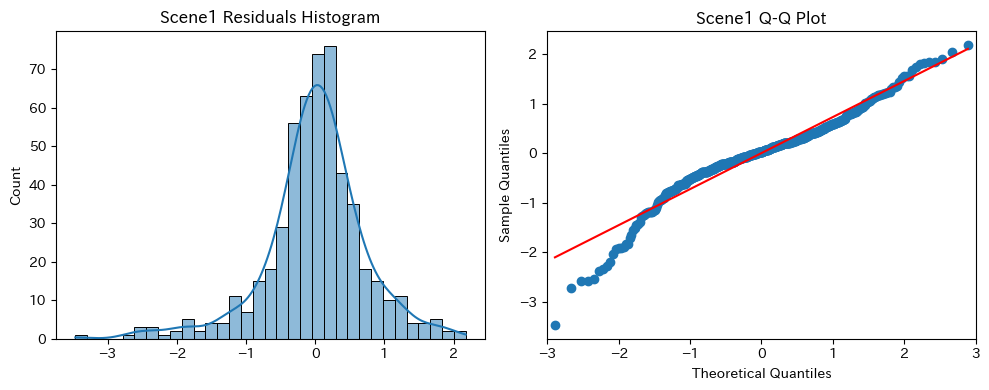


=== Scene2 残差の正規性チェック ===
Shapiro-Wilk: W=0.921, p=8.1e-15
Anderson-Darling: stat=8.969, crit=[0.571 0.65  0.78  0.91  1.083]
Jarque-Bera: JB=569.677, p=1.98e-124
Skewness=-0.645, Kurtosis=5.297


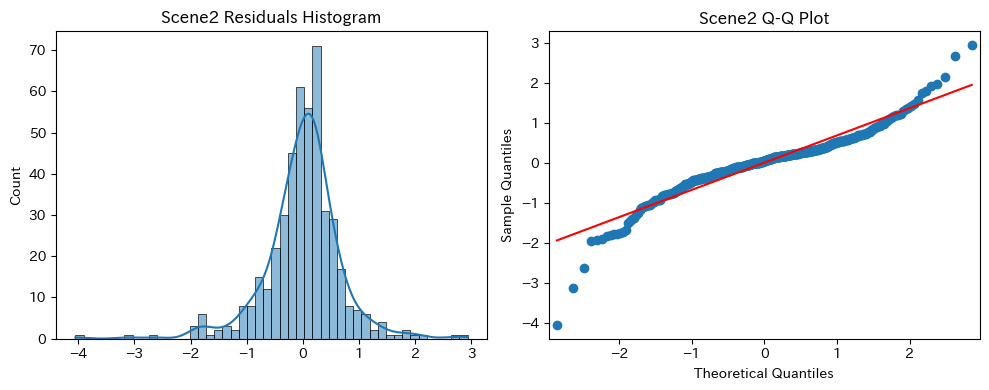

In [10]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

def check_residuals(df_scene, scene_label):
    print(f"\n=== {scene_label} 残差の正規性チェック ===")
    
    # 2×2（within–within）の混合効果モデル
    model = mixedlm("score_mean ~ Conflict * Presentation",
                    data=df_scene,
                    groups=df_scene["subject"])
    result = model.fit()
    
    # 残差
    residuals = result.resid
    
    # --- 正規性検定 ---
    # Shapiro–Wilk
    W, p_shapiro = stats.shapiro(residuals)
    print(f"Shapiro-Wilk: W={W:.3f}, p={p_shapiro:.3g}")
    
    # Anderson–Darling
    ad_result = stats.anderson(residuals, dist='norm')
    print(f"Anderson-Darling: stat={ad_result.statistic:.3f}, crit={ad_result.critical_values}")
    
    # Jarque–Bera
    jb_stat, jb_p = stats.jarque_bera(residuals)
    print(f"Jarque-Bera: JB={jb_stat:.3f}, p={jb_p:.3g}")
    
    # 歪度・尖度
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals)  # Fisher補正あり（正規分布なら0）
    print(f"Skewness={skewness:.3f}, Kurtosis={kurtosis:.3f}")
    
    # --- 可視化（ヒストグラム＋QQプロット） ---
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    
    # ヒストグラム
    sns.histplot(residuals, kde=True, ax=axes[0])
    axes[0].set_title(f"{scene_label} Residuals Histogram")
    
    # QQプロット
    sm.qqplot(residuals, line='s', ax=axes[1])
    axes[1].set_title(f"{scene_label} Q-Q Plot")
    
    plt.tight_layout()
    plt.show()
    
    return residuals

resid1 = check_residuals(df1, "Scene1")
resid2 = check_residuals(df2, "Scene2")


In [11]:
# 4条件のデータをフィルタ
cond = lambda c, p: (df1["Conflict"] == c) & (df1["Presentation"] == p)

df_NC_Seq = df1[cond("NoConflict", "Sequential")].sort_values("subject")
df_NC_Sim = df1[cond("NoConflict", "Simultaneous")].sort_values("subject")
df_C_Seq  = df1[cond("Conflict", "Sequential")].sort_values("subject")
df_C_Sim  = df1[cond("Conflict", "Simultaneous")].sort_values("subject")

df_NC_Seq2 = df2[cond("NoConflict", "Sequential")].sort_values("subject")
df_NC_Sim2 = df2[cond("NoConflict", "Simultaneous")].sort_values("subject")
df_C_Seq2 = df2[cond("Conflict", "Sequential")].sort_values("subject")
df_C_Sim2 = df2[cond("Conflict", "Simultaneous")].sort_values("subject")

C:\Users\yuki4\AppData\Local\Temp\ipykernel_47944\1381709497.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_NC_Seq2 = df2[cond("NoConflict", "Sequential")].sort_values("subject")
C:\Users\yuki4\AppData\Local\Temp\ipykernel_47944\1381709497.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_NC_Sim2 = df2[cond("NoConflict", "Simultaneous")].sort_values("subject")
C:\Users\yuki4\AppData\Local\Temp\ipykernel_47944\1381709497.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_C_Seq2 = df2[cond("Conflict", "Sequential")].sort_values("subject")
C:\Users\yuki4\AppData\Local\Temp\ipykernel_47944\1381709497.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_C_Sim2 = df2[cond("Conflict", "Simultaneous")].sort_values("subject")


In [12]:
from scipy.stats import wilcoxon

# 葛藤なし：同時 vs 連続
w1 = wilcoxon(df_NC_Sim["score_mean"], df_NC_Seq["score_mean"])
print("葛藤なし - 同時 vs 連続：", w1)

# 葛藤あり：同時 vs 連続
w2 = wilcoxon(df_C_Sim["score_mean"], df_C_Seq["score_mean"])
print("葛藤あり - 同時 vs 連続：", w2)

# 同時：葛藤なし vs あり
w3 = wilcoxon(df_NC_Sim["score_mean"], df_C_Sim["score_mean"])
print("同時 - 葛藤なし vs あり：", w3)

# 連続：葛藤なし vs あり
w4 = wilcoxon(df_NC_Seq["score_mean"], df_C_Seq["score_mean"])
print("連続 - 葛藤なし vs あり：", w4)

葛藤なし - 同時 vs 連続： WilcoxonResult(statistic=np.float64(2165.5), pvalue=np.float64(0.4470491677026317))
葛藤あり - 同時 vs 連続： WilcoxonResult(statistic=np.float64(1680.5), pvalue=np.float64(0.012165588697569635))
同時 - 葛藤なし vs あり： WilcoxonResult(statistic=np.float64(1674.5), pvalue=np.float64(0.00039163264027700106))
連続 - 葛藤なし vs あり： WilcoxonResult(statistic=np.float64(2293.0), pvalue=np.float64(0.023378733237409424))


In [13]:
from scipy.stats import wilcoxon

# 葛藤なし：同時 vs 連続
w1 = wilcoxon(df_NC_Sim2["score_mean"], df_NC_Seq2["score_mean"])
print("葛藤なし - 同時 vs 連続：", w1)

# 葛藤あり：同時 vs 連続
w2 = wilcoxon(df_C_Sim2["score_mean"], df_C_Seq2["score_mean"])
print("葛藤あり - 同時 vs 連続：", w2)

# 同時：葛藤なし vs あり
w3 = wilcoxon(df_NC_Sim2["score_mean"], df_C_Sim2["score_mean"])
print("同時 - 葛藤なし vs あり：", w3)

# 連続：葛藤なし vs あり
w4 = wilcoxon(df_NC_Seq2["score_mean"], df_C_Seq2["score_mean"])
print("連続 - 葛藤なし vs あり：", w4)

葛藤なし - 同時 vs 連続： WilcoxonResult(statistic=np.float64(2236.5), pvalue=np.float64(0.6139569419086712))
葛藤あり - 同時 vs 連続： WilcoxonResult(statistic=np.float64(2017.5), pvalue=np.float64(0.14774090225278005))
同時 - 葛藤なし vs あり： WilcoxonResult(statistic=np.float64(1448.5), pvalue=np.float64(0.0012990004852080172))
連続 - 葛藤なし vs あり： WilcoxonResult(statistic=np.float64(1867.0), pvalue=np.float64(0.03371983346572903))


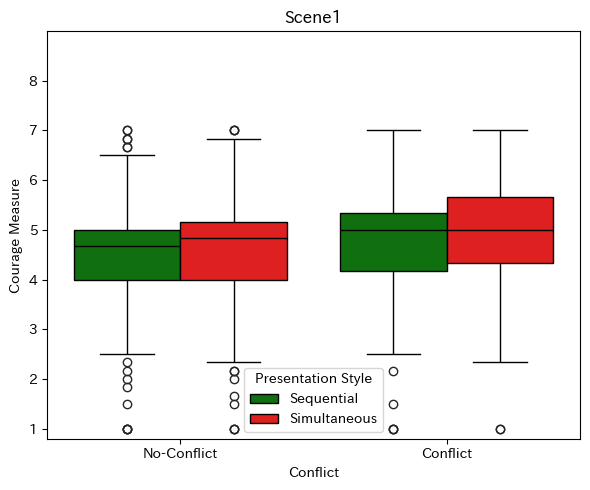

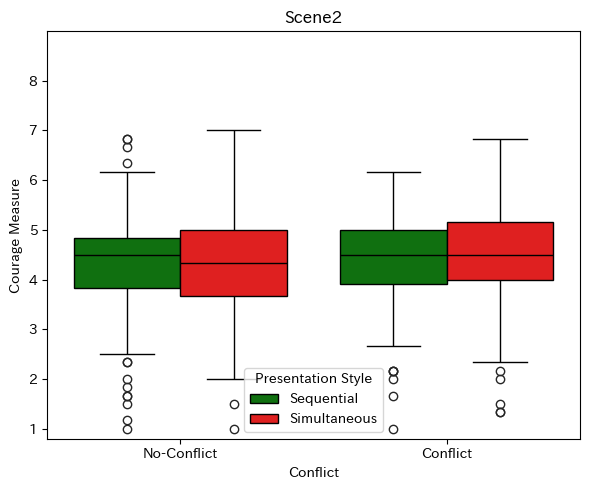

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_box_conflict_presentation(df, title=None):
    # カラーマッピング
    color_map = {
        "Sequential": "green",
        "Simultaneous": "red"
    }

    # Presentation列の英語表記をそのまま使う
    df = df.copy()
    df["Presentation Style"] = df["Presentation"].replace({
        "Sequential": "Sequential",
        "Simultaneous": "Simultaneous"
    })
    df["Conflict"] = df["Conflict"].replace({
        "NoConflict": "No-Conflict",
        "Conflict": "Conflict"
    })

    # 描画
    plt.figure(figsize=(6, 5))
    sns.boxplot(
        data=df,
        x="Conflict",
        y="score_mean",
        hue="Presentation Style",
        palette=color_map,
        order=["No-Conflict","Conflict"],  # 順番を指定
        boxprops=dict(edgecolor="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1)
    )

    plt.ylim(0.8, 8.99)
    plt.ylabel("Courage Measure")  # 縦軸ラベル
    if title:
        plt.title(title)

    # 凡例
    plt.legend(
        title="Presentation Style",
        frameon=True,
        loc="lower center",
        bbox_to_anchor=(0.5, 0),
        ncol=1
    )
    plt.tight_layout()
    plt.show()

# 実行例
plot_box_conflict_presentation(df1, title="Scene1")
plot_box_conflict_presentation(df2, title="Scene2")
